In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

Question 1: Preprocessing. How are you handling nulls? What process(es) are you using to encode and normalize the data?


In [3]:
customer_df = pd.read_csv("data.csv")
customer_df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
customer_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
customer_df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [6]:
def preprocessing_data(customer_df):
    customer_df['CustomerID'] = customer_df['CustomerID'].fillna(customer_df['CustomerID'].median())
    customer_df['Quantity'] = customer_df['Quantity'].fillna(customer_df['Quantity'].median())

    customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])

    customer_df['TotalPrice'] = customer_df['Quantity'] * customer_df['UnitPrice']
    return customer_df


def encode_to_numbers(customer_df):
    country_map = {
        'United Kingdom': 1,'France': 2, 'Australia': 3, 'Netherlands': 4, 'Germany':5,
        'Norway':6, 'EIRE': 7, 'Switzerland': 8, 'Spain':9, 'Poland': 10, 'Portugal':11,
        'Italy':12, 'Belgium':13, 'Lithuania':14, 'Japan':15, 'Iceland':16,
        'Channel Islands':17, 'Denmark':18, 'Cyprus':19, 'Sweden':20, 'Austria':21,
        'Israel':22, 'Finland':23, 'Bahrain':24, 'Greece':25, 'Hong Kong':26, 'Singapore':27,
        'Lebanon':28, 'United Arab Emirates':29, 'Saudi Arabia':30,
        'Czech Republic':31, 'Canada':32, 'Unspecified':33, 'Brazil':34, 'USA':35,
        'European Community':36, 'Malta':37, 'RSA':38}

    customer_df['Country'] = customer_df['Country'].map(country_map)
    return customer_df

def extract_date_features(customer_df):
    customer_df['Year'] = customer_df['InvoiceDate'].dt.year
    customer_df['Month'] = customer_df['InvoiceDate'].dt.month
    return customer_df


def run(df):
    customer_df = preprocessing_data(df)
    customer_df = encode_to_numbers(customer_df)
    return customer_df

result = run(customer_df)
print(result.head())



  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID  Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0        1       15.30  
1 2010-12-01 08:26:00       3.39     17850.0        1       20.34  
2 2010-12-01 08:26:00       2.75     17850.0        1       22.00  
3 2010-12-01 08:26:00       3.39     17850.0        1       20.34  
4 2010-12-01 08:26:00       3.39     17850.0        1       20.34  


Question 2: Perform k-means on this dataset for customer segments. Customer segments help determine what types of people buy your product, which allows you to target more people like your usual customers. Should you look at all the data, or which subset of data should you use? What is the ideal number of clusters? Which approach did you use to find the ideal number of clusters and why?


In [7]:
newcustomer_df = customer_df[['Quantity','UnitPrice','TotalPrice','Country']]

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = customer_df.drop(['InvoiceNo','StockCode','Description','InvoiceDate'], axis=1)
y = customer_df['Country']

X_scaled = StandardScaler().fit_transform(X)
plt.scatter(X['Quantity'], X['TotalPrice'])

for i, txt in enumerate(y):
    plt.annotate(txt, (X['Quantity'][i], X['TotalPrice'][i]))

plt.xlabel('Quantity')
plt.ylabel('TotalPrice')
plt.show()

KeyboardInterrupt: 

There are a few ourliers in this graph.

In [1]:
inertias = []
distortions = []

for k in range(1,10):
    model = KMeans(n_clusters=k).fit(X)

    distance = cdist(X, model.cluster_centers_, 'euclidean')
    distortion = sum(np.min(distance, axis=1))/X.shape[0]
    distortions.append(distortion)


    inertia = model.inertia_
    inertias.append(inertia)

NameError: name 'KMeans' is not defined

Text(0.5, 1.0, 'Elbow method with Distortion')

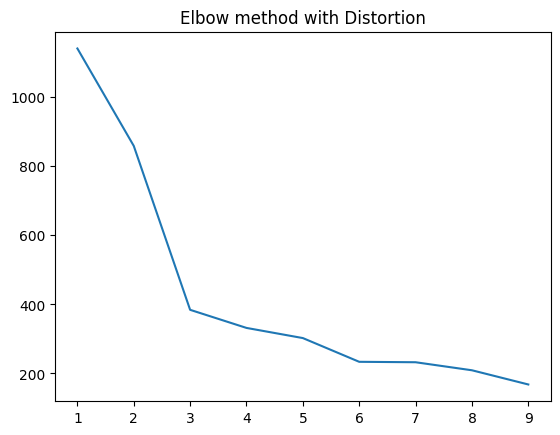

In [ ]:
plt.plot(range(1,10), distortions)
plt.title('Elbow method with Distortion')

Text(0.5, 1.0, 'Elbow Method with Inertia')

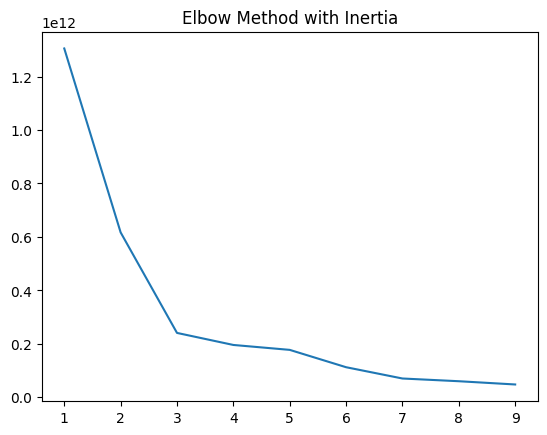

In [ ]:
plt.plot(range(1,10), inertias)
plt.title('Elbow Method with Inertia')

Question 3: Perform hierarchical clustering for customer segments. What is the ideal number of clusters? Which approach did you use to find the ideal number of clusters and why?


In [ ]:
firstsample_df = customer_df.sample(n=5000, random_state=42)
X = firstsample_df.drop(['InvoiceNo','StockCode','Description','InvoiceDate'], axis=1)
y = firstsample_df['Country']
X_scaled = StandardScaler().fit_transform(X)

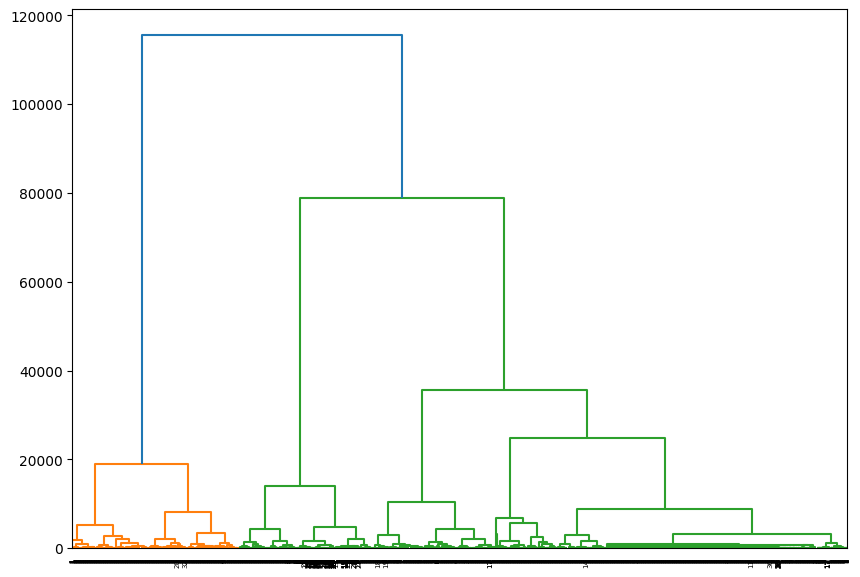

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X, 'ward')
plt.figure(figsize=(10,7))

dendro = dendrogram(linked, labels = list(y))

In [ ]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster.fit_predict(X)

array([1, 0, 0, ..., 1, 2, 1], shape=(5000,))

KeyError: 0

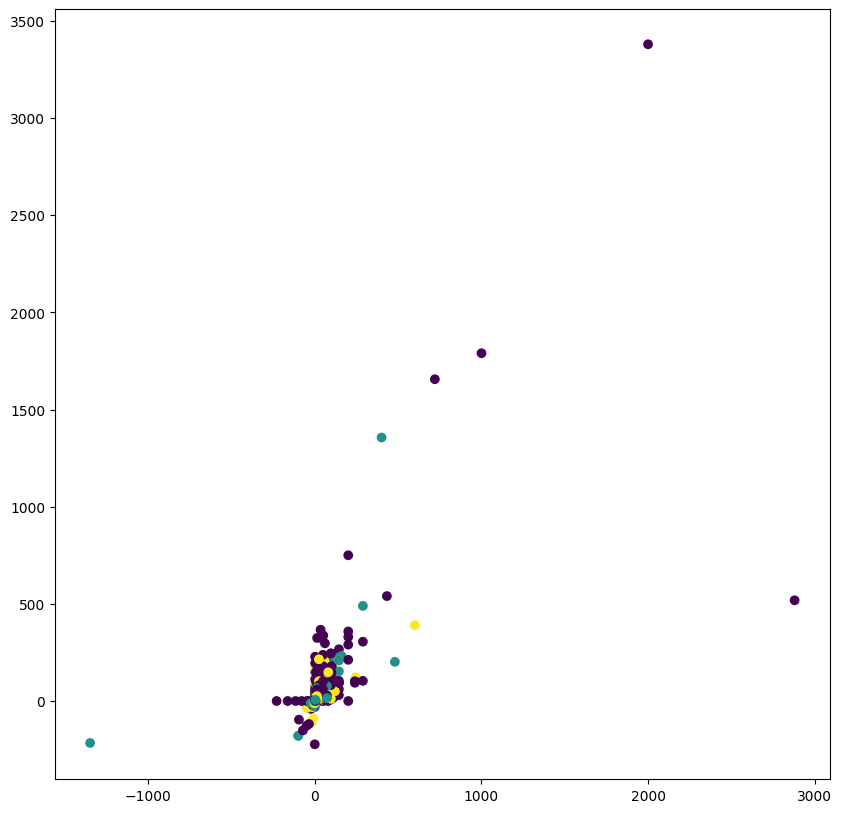

: 

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(X['Quantity'],X['TotalPrice'],c=cluster.labels_)
for i, txt in enumerate(y):
    plt.annotate(txt, (X['Quantity'][i],X['TotalPrice'][i]))

plt.xlabel('Quantity')
plt.ylabel('TotalPrice')
plt.show()


Question 4: Compare the results of 2 and 3. Which approach do you think is best? Why?
